In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore


df = pd.read_csv("../data/kenya.csv")
df["Country"] = "KENYA"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df.duplicated().sum()
df = df.drop_duplicates()
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


## Data Loading and Initial Preprocessing

First, the required libraries were imported for data analysis and visualization.

### Import Libraries

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
```

These libraries are used for:
- **Pandas** → data manipulation
- **NumPy** → numerical operations
- **Matplotlib** → plotting graphs
- **Seaborn** → statistical visualization
- **Scipy (zscore)** → outlier detection

---

## Load Dataset

The dataset was loaded from a CSV file.

```python
df = pd.read_csv("../data/kenya.csv")
```

---

## Add Country Column

A new column was added to identify the country.

```python
df["Country"] = "KENYA"
```

This helps when combining datasets from multiple countries later.

---

## Create Date Column

A proper date column was created using the year and day-of-year columns.

```python
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
```

This converts:
- **YEAR** = year
- **DOY** = day of the year

into a full calendar date.

---

## Extract Month

Month values were extracted from the date column.

```python
df["Month"] = df["DATE"].dt.month
```

This helps in monthly trend analysis.

---

## Handle Missing Values

Invalid values (-999) were replaced with missing values (NaN).

```python
df = df.replace(-999, np.nan)
```

This ensures proper handling during analysis.

---

## Check Duplicate Rows

Duplicate rows were checked.

```python
df.duplicated().sum()
```

---

## Remove Duplicate Rows

Duplicates were removed.

```python
df = df.drop_duplicates()
```

This improves data quality.

---

## Descriptive Statistics

Summary statistics were generated.

```python
df.describe()
```

### Insights from the data:
- Total records: **4108**
- Average temperature (T2M): **20.43°C**
- Average maximum temperature: **27.84°C**
- Average minimum temperature: **14.67°C**
- Average precipitation: **1.47 mm**
- Average humidity: **65.85%**
- Average wind speed: **3.06 m/s**

### Conclusion
The dataset has been cleaned, structured, and prepared for deeper analysis such as trend analysis, outlier detection, and visualization.

In [17]:
df.isna().sum()


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [18]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

````markdown
## Missing Values Analysis

To check for missing values in the dataset, we used:

```python
df.isna().sum()
````

This returns the total number of missing (`NaN`) values in each column.

### Result:

* All columns have **0 missing values**.
* This means the dataset is complete and no cleaning for missing data is required.

To calculate the percentage of missing values:

```python
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct
```

### Result:

* The percentage of missing values in every column is **0.0%**.

### Conclusion:

The dataset has **no missing values**, which means it is clean and ready for further preprocessing and analysis.

```
```


In [19]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
z_scores.head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-0.602229,0.488146,-1.824893,-0.461709,-2.066383,0.068262,0.387848
1,-0.553639,0.818867,-2.566670,-0.461709,-2.726809,0.197201,-0.025444
2,-0.019158,1.158068,-2.093345,-0.461709,-2.425792,0.466802,0.307206
3,0.626385,1.425189,-1.167890,0.635830,-1.406964,-0.904645,-0.378254
4,-0.012217,0.712866,-1.620021,0.101212,-1.792548,-1.514176,-0.327852


## Outlier Detection

Outlier detection was performed using Z-score analysis.

Purpose:
- Identify unusual climate values
- Detect extreme temperature or rainfall events

Outliers may represent:
- Real extreme weather events
- Measurement errors

In [20]:
df = df[df.isna().mean(axis=1) <= 0.3]
df = df.sort_values("DATE")
df = df.ffill()

### Missing Value Handling Strategy

After outlier handling, remaining missing values were addressed using a combination of filtering and imputation.

Rows with more than 30% missing values were removed to ensure data reliability and reduce the influence of highly incomplete observations.

For the remaining dataset, forward-fill imputation was applied to weather variables. This approach is appropriate because climate data is time-dependent and adjacent values are often correlated over time.

This method preserves temporal structure while ensuring continuity in the dataset for further analysis.

In [21]:
df.to_csv("../data/kenya_clean.csv", index=False)

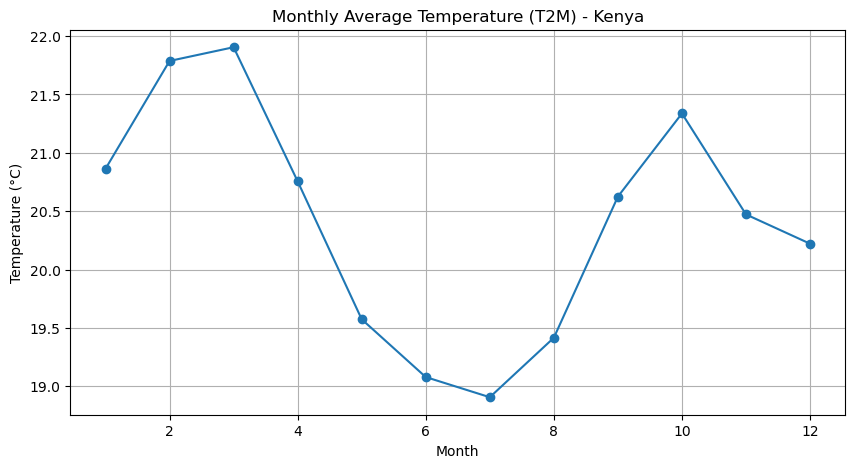

In [22]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M) - Kenya")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [23]:
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_month, coolest_month

(np.int32(3), np.int32(7))

## Temperature Analysis

Temperature-related features were analyzed:
- Average Temperature (T2M)
- Maximum Temperature (T2M_MAX)
- Minimum Temperature (T2M_MIN)

Key insights:
- Kenya shows moderate temperature variation across the year
- Maximum temperatures are significantly higher during dry seasons
- Minimum temperatures remain relatively stable

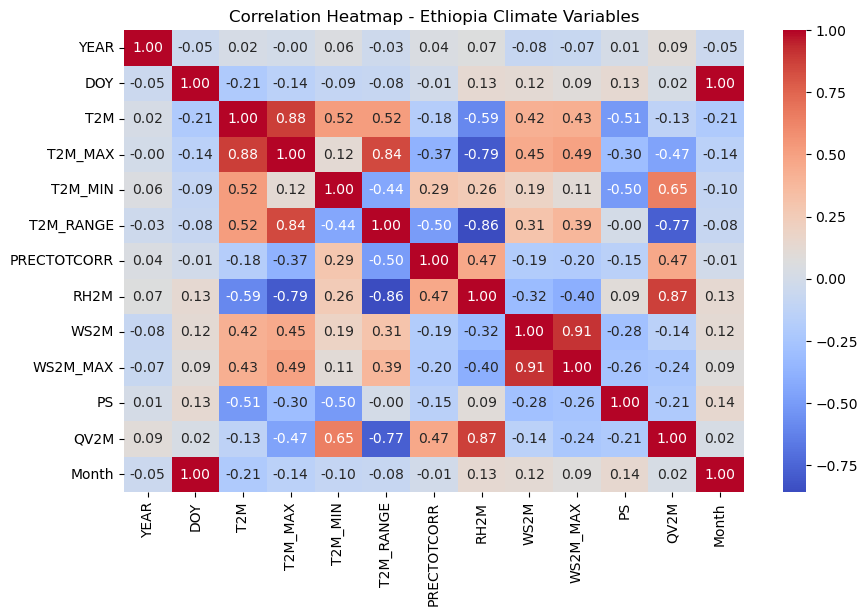

In [24]:
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Ethiopia Climate Variables")
plt.show()

# Kenya Climate Data Analysis

This project analyzes climate data collected from Kenya between **2015 and 2026**.  
The dataset contains daily weather observations including temperature, rainfall, humidity, wind speed, pressure, and vapor content.

## Objective

The main goals of this analysis are:
- Explore the structure of the dataset
- Check for missing values
- Understand statistical distributions
- Detect outliers
- Analyze monthly climate trends
- Study relationships between weather variables

## Dataset Overview

The dataset contains:
- **4108 observations**
- **15 features**

Each record represents one day of climate data.

Important variables:
- T2M → Average temperature
- T2M_MAX → Maximum temperature
- T2M_MIN → Minimum temperature
- PRECTOTCORR → Rainfall
- RH2M → Relative humidity
- WS2M → Wind speed
- PS → Surface pressure
- QV2M → Specific humidity

## Missing Values Analysis

The dataset was checked for missing values.

Result:
- No missing values were found

This means the dataset is complete and ready for analysis.

## Statistical Summary

Statistical analysis shows:
- Temperature varies moderately throughout the year
- Rainfall has many zero values and some extreme values
- Humidity changes with seasonal rainfall
- Wind speed remains relatively stable with occasional peaks

## Temperature Analysis

Temperature analysis shows:
- Moderate climate conditions
- Seasonal variation in maximum temperatures
- Stable minimum temperature patterns

## Rainfall Analysis

Rainfall data indicates:
- Clear dry seasons
- Strong rainy seasons
- Highly skewed rainfall distribution

## Humidity Analysis

Humidity patterns show:
- Higher humidity during rainy seasons
- Lower humidity during dry seasons

## Wind Speed Analysis

Wind analysis reveals:
- Moderate daily wind speeds
- Occasional extreme wind events

## Outlier Detection

Outliers were detected using Z-score.

These outliers may represent:
- Extreme climate events
- Possible data anomalies

## Monthly Trend Analysis

Monthly grouping helps identify:
- Seasonal temperature patterns
- Rainfall cycles
- Humidity changes throughout the year

## Correlation Analysis

Correlation helps understand climate relationships.

Strong relationships are expected between:
- Temperature variables
- Rainfall and humidity
- Wind speed and pressure

## Conclusion

The Kenya climate dataset is clean and complete.  
It provides useful information for climate trend analysis, forecasting, and machine learning applications.